# ДЗ 1 — Обучаемые функции

### Импорты


In [1]:
from abc import ABC, abstractmethod
from typing import Any, Callable, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


### Активации и перекрёстная энтропия (п. 2, 5)


Формулы блока: `identity(x)=x`, `ReLU(x)=max(0,x)`, `tanh(x)`, и стабилизированная кросс-энтропия через `log_softmax`.

In [2]:


def identity_forward(x: np.ndarray) -> Tuple[np.ndarray, None]:
    return x, None


def identity_backward(dout: np.ndarray, _: None) -> np.ndarray:
    return dout


def relu_forward(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    mask = x > 0
    return np.where(mask, x, 0.0), mask


def relu_backward(dout: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return dout * mask


def tanh_forward(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    out = np.tanh(x)
    return out, out


def tanh_backward(dout: np.ndarray, tanh_out: np.ndarray) -> np.ndarray:
    return dout * (1.0 - tanh_out**2)


ACTIVATIONS: Dict[str, Tuple[Callable, Callable]] = {
    "identity": (identity_forward, identity_backward),
    "relu": (relu_forward, relu_backward),
    "tanh": (tanh_forward, tanh_backward),
}




def log_softmax(x: np.ndarray, axis: int) -> np.ndarray:
    m = np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x - m)
    s = np.sum(ex, axis=axis, keepdims=True)
    return x - m - np.log(s)


def softmax(x: np.ndarray, axis: int) -> np.ndarray:
    return np.exp(log_softmax(x, axis=axis))


def soft_argmax_cross_entropy_forward(
    logits: np.ndarray, target: np.ndarray,
) -> Tuple[float, Tuple[np.ndarray, np.ndarray]]:
    log_p = log_softmax(logits, axis=-1)
    n = logits.shape[0]
    loss = -np.sum(target * log_p) / n
    return float(loss), (logits, target)


def soft_argmax_cross_entropy_backward(
    dout: float, cache: Tuple[np.ndarray, np.ndarray],
) -> np.ndarray:
    logits, target = cache
    n = logits.shape[0]
    p = softmax(logits, axis=-1)
    return dout * (p - target) / n


### Базовый класс, `AffineActivation`, `RBFGaussianLayer` (п. 2, 3)

Формулы блока: affine-слой `y = phi(Wx + b)`, RBF-слой `y_j = exp(-gamma ||x-c_j||^2)`, с вычислением градиентов по входу и параметрам.

In [3]:
class Module(ABC):
    params: Dict[str, np.ndarray] = {}
    grads: Dict[str, np.ndarray] = {}

    @abstractmethod
    def forward(self, x: np.ndarray) -> np.ndarray:
        pass

    @abstractmethod
    def backward(self, dout: np.ndarray) -> np.ndarray:
        pass

    def zero_grad(self) -> None:
        for k in self.grads:
            self.grads[k].fill(0.0)


class AffineActivation(Module):
    """y = act(W @ x + b)."""

    def __init__(self, in_dim: int, out_dim: int, activation: str = "relu") -> None:
        lim = np.sqrt(2.0 / (in_dim + out_dim))
        self.W = np.random.uniform(-lim, lim, (out_dim, in_dim)).astype(np.float64)
        self.b = np.zeros((out_dim,), dtype=np.float64)
        self.params = {"W": self.W, "b": self.b}
        self.grads = {"W": np.zeros_like(self.W), "b": np.zeros_like(self.b)}
        self._act_fwd, self._act_bwd = ACTIVATIONS[activation]
        self._cache: Tuple[np.ndarray, object] | None = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        z = x @ self.W.T + self.b
        a, act_cache = self._act_fwd(z)
        self._cache = (x, act_cache)
        return a

    def backward(self, dout: np.ndarray) -> np.ndarray:
        x, act_cache = self._cache
        dz = self._act_bwd(dout, act_cache)
        self.grads["W"] += dz.T @ x
        self.grads["b"] += np.sum(dz, axis=0)
        return dz @ self.W


class RBFGaussianLayer(Module):
    """exp(-gamma * ||x - c_j||^2)"""

    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        gamma: float,
        init_X: np.ndarray | None,
    ) -> None:
        use_km = (
            init_X is not None
            and init_X.shape[0] >= out_dim
            and init_X.shape[1] == in_dim
        )
        lim = np.sqrt(1.0 / in_dim)
        if use_km:
            Xm = init_X[:5000]
            km = KMeans(n_clusters=out_dim, random_state=1216, n_init=10)
            km.fit(Xm)
            self.C = km.cluster_centers_.astype(np.float64)
        else:
            self.C = np.random.uniform(-lim, lim, (out_dim, in_dim)).astype(np.float64)

        self.gamma = float(gamma)

        self.params: Dict[str, np.ndarray] = {"C": self.C}
        self.grads = {"C": np.zeros_like(self.C)}
        self._cache: Tuple[np.ndarray, np.ndarray, np.ndarray, float] | None = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        g = self.gamma
        diff = x[:, np.newaxis, :] - self.C[np.newaxis, :, :]
        d2 = np.sum(diff**2, axis=2)
        out = np.exp(-g * d2)
        self._cache = (diff, d2, out, g)
        return out

    def backward(self, dout: np.ndarray) -> np.ndarray:
        diff, d2, out, g = self._cache
        chain = dout * out
        d_diff = -2.0 * g * chain[:, :, np.newaxis] * diff
        dx = np.sum(d_diff, axis=1)
        self.grads["C"] += -np.sum(d_diff, axis=0)
        return dx



### `Residual`, `Sequential`, `Adam` (п. 4, 6)


Формулы блока: residual-связь `y = x + F(x)`, оптимизатор Adam: обновления по моментам `m_t`, `v_t` и шаг `w <- w - lr * m_hat / (sqrt(v_hat)+eps)`.

In [4]:


class Residual(Module):
    """y = x + F(x)."""

    def __init__(self, inner: Module) -> None:
        self.inner = inner
        self.params = inner.params
        self.grads = inner.grads

    def forward(self, x: np.ndarray) -> np.ndarray:
        return x + self.inner.forward(x)

    def backward(self, dout: np.ndarray) -> np.ndarray:
        dx_inner = self.inner.backward(dout)
        return dout + dx_inner


class Sequential(Module):
    def __init__(self, layers: List[Module]) -> None:
        self.layers = layers
        self.params = {}
        self.grads = {}
        for i, layer in enumerate(layers):
            prefix = f"L{i}_"
            for k, v in layer.params.items():
                self.params[prefix + k] = v
            for k, v in layer.grads.items():
                self.grads[prefix + k] = v

    def forward(self, x: np.ndarray) -> np.ndarray:
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, dout: np.ndarray) -> np.ndarray:
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def zero_grad(self) -> None:
        for layer in self.layers:
            layer.zero_grad()


class Adam:
    def __init__(
        self,
        params: Dict[str, np.ndarray],
        grads: Dict[str, np.ndarray],
        lr: float = 1e-3,
        beta1: float = 0.9,
        beta2: float = 0.999,
        eps: float = 1e-8,
    ) -> None:
        self.params = params
        self.grads = grads
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.m: Dict[str, np.ndarray] = {k: np.zeros_like(v) for k, v in params.items()}
        self.v: Dict[str, np.ndarray] = {k: np.zeros_like(v) for k, v in params.items()}

    def step(self) -> None:
        self.t += 1
        t = self.t
        for k in self.params:
            g = self.grads[k]
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (g * g)
            m_hat = self.m[k] / (1 - self.beta1**t)
            v_hat = self.v[k] / (1 - self.beta2**t)
            self.params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


def count_params(model: Module) -> int:
    return int(sum(np.size(v) for v in model.params.values()))



### Данные, one-hot, эпоха, `evaluate` (п. 1)


Функции блока: one-hot кодирование, расчёт лосса и метрик по эпохе, `evaluate` (accuracy и macro-F1).

In [5]:


def load_tabular_multiclass(
    test_size: float,
    random_state: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    data = load_wine()
    X, y = data.data, data.target
    feature_names = list(data.feature_names)

    scaler = StandardScaler()
    X = scaler.fit_transform(X.astype(np.float64))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test, feature_names


def one_hot(y: np.ndarray, num_classes: int) -> np.ndarray:
    out = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    out[np.arange(y.shape[0]), y] = 1.0
    return out


def train_epoch(
    model: Sequential,
    opt: Adam,
    X: np.ndarray,
    y_oh: np.ndarray,
    batch_size: int,
) -> float:
    n = X.shape[0]
    idx = np.random.permutation(n)
    total_loss = 0.0
    for start in range(0, n, batch_size):
        sl = idx[start : start + batch_size]
        xb, yb = X[sl], y_oh[sl]
        model.zero_grad()
        logits = model.forward(xb)
        loss, cache = soft_argmax_cross_entropy_forward(logits, yb)
        dlogits = soft_argmax_cross_entropy_backward(1.0, cache)
        model.backward(dlogits)
        opt.step()
        total_loss += loss * xb.shape[0]
    return total_loss / n


def evaluate(model: Sequential, X: np.ndarray, y: np.ndarray) -> Tuple[float, float]:
    logits = model.forward(X)
    pred = np.argmax(logits, axis=1)
    return accuracy_score(y, pred), f1_score(y, pred, average="weighted")


### Сборка MLP и `run_training_curves` (п. 7–9)


Функции блока: сборка архитектур (Affine / RBF / Mixed), цикл обучения `run_training_curves`, подсчёт `accuracy` и `macro-F1` на тесте.

In [6]:


def build_mlp_affine(
    d_in: int,
    num_classes: int,
    n_affine: int,
    hidden: int,
    activation: str,
    use_residual: bool,
) -> Sequential:
    layers: List[Module] = []
    if n_affine == 1:
        layers.append(AffineActivation(d_in, num_classes, activation=activation))
        return Sequential(layers)

    layers.append(AffineActivation(d_in, hidden, activation=activation))
    for _ in range(n_affine - 2):
        block = AffineActivation(hidden, hidden, activation=activation)
        layers.append(Residual(block) if use_residual else block)
    layers.append(AffineActivation(hidden, num_classes, activation="identity"))
    return Sequential(layers)


def build_mlp_rbf(
    d_in: int,
    num_classes: int,
    n_rbf: int,
    hidden: int,
    gamma: float,
    tail_activation: str,
    use_residual: bool,
    init_X: np.ndarray | None,
) -> Sequential:
    layers: List[Module] = []
    if n_rbf == 1:
        layers.append(RBFGaussianLayer(d_in, num_classes, gamma=gamma, init_X=init_X))
        return Sequential(layers)

    layers.append(RBFGaussianLayer(d_in, hidden, gamma=gamma, init_X=init_X))
    layers.append(AffineActivation(hidden, hidden, activation=tail_activation))
    for _ in range(n_rbf - 2):
        r = RBFGaussianLayer(hidden, hidden, gamma=gamma, init_X=init_X)
        layers.append(Residual(r) if use_residual else r)
        layers.append(AffineActivation(hidden, hidden, activation=tail_activation))
    layers.append(RBFGaussianLayer(hidden, num_classes, gamma=gamma, init_X=init_X))
    return Sequential(layers)


def build_mlp_mixed(
    d_in: int,
    num_classes: int,
    n_blocks: int,
    hidden: int,
    activation: str,
    gamma: float,
    use_residual: bool,
    init_X: np.ndarray | None,
) -> Sequential:
    layers: List[Module] = []
    cur = d_in
    for i in range(n_blocks - 1):
        if i % 2 == 0:
            layers.append(AffineActivation(cur, hidden, activation=activation))
            cur = hidden
        else:
            r = RBFGaussianLayer(cur, hidden, gamma=gamma, init_X=init_X)
            layers.append(Residual(r) if use_residual else r)
            cur = hidden
    if n_blocks % 2 == 1:
        layers.append(AffineActivation(cur, num_classes, activation="identity"))
    else:
        layers.append(RBFGaussianLayer(cur, num_classes, gamma=gamma, init_X=init_X))
    return Sequential(layers)


def run_training_curves(
    name: str,
    build_fn: Callable[..., Sequential],
    build_kw: Dict[str, Any],
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    epochs: int,
    batch_size: int,
    lr: float,
    n_transforms_key: str,
) -> Dict[str, Any]:
    num_classes = int(y_train.max()) + 1
    y_oh = one_hot(y_train, num_classes)
    model = build_fn(**build_kw)
    opt = Adam(model.params, model.grads, lr=lr)
    history = []
    for _ep in range(epochs):
        loss = train_epoch(model, opt, X_train, y_oh, batch_size)
        acc_tr, _ = evaluate(model, X_train, y_train)
        acc_te, f1_te = evaluate(model, X_test, y_test)
        history.append({"loss": loss, "acc_train": acc_tr, "acc_test": acc_te, "f1_test": f1_te})
    n_tr = int(build_kw.get(n_transforms_key, 0))
    return {
        "name": name,
        "history": history,
        "params": count_params(model),
        "test_acc": history[-1]["acc_test"],
        "test_f1": history[-1]["f1_test"],
        "n_transforms": n_tr,
    }


def format_run_label(name: str) -> str:
    if name.startswith("affine_L"):
        n = name.split("_L", 1)[1].split("_", 1)[0]
        res = " + residual" if name.endswith("_res") else ""
        return f"Affine layers={n}{res}"
    if name.startswith("rbf_L"):
        n = name.split("_L", 1)[1].split("_", 1)[0]
        res = " + residual" if name.endswith("_res") else ""
        return f"RBF layers={n}{res}"
    if name.startswith("mixed_B"):
        n = name.split("_B", 1)[1].split("_", 1)[0]
        res = " + residual" if name.endswith("_res") else ""
        return f"Mixed blocks={n}{res}"
    return name


def scatter_test_points(
    axis: Any,
    results: List[Dict[str, Any]],
    xkey: str,
    spread: float,
) -> None:
    grouped_by_x = {}
    for result in results:
        x_value = float(result[xkey])
        grouped_by_x.setdefault(x_value, []).append(result)
    for x_value in sorted(grouped_by_x.keys()):
        result_group = grouped_by_x[x_value]
        group_size = len(result_group)
        if group_size == 1:
            axis.scatter(
                x_value,
                result_group[0]["test_acc"],
                label=format_run_label(result_group[0]["name"]),
            )
            continue
        for offset_idx, result in enumerate(result_group):
            x_offset = x_value + spread * (2 * offset_idx / (group_size - 1) - 1)
            axis.scatter(x_offset, result["test_acc"], label=format_run_label(result["name"]))



## Загрузка и предобработка данных (п. 1)

Табличный датасет **Wine** (3 класса, 13 признаков).

Функции блока: предобработка табличных данных (split, имputation/нормализация), подготовка `X_train/X_test`, `y_train/y_test`.

In [7]:
X_train, X_test, y_train, y_test, feature_names = load_tabular_multiclass(
    test_size=0.3,
    random_state=1216,
)
d_in = X_train.shape[1]
num_classes = int(max(y_train.max(), y_test.max())) + 1
print(f"Признаков: {d_in}, классов: {num_classes}")
print(f"Train: {X_train.shape[0]}, test: {X_test.shape[0]}")
print("Имена признаков:", feature_names)


Признаков: 13, классов: 3
Train: 124, test: 54
Имена признаков: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## Гиперпараметры экспериментов (п. 7–9)

In [8]:
EPOCHS = 100
BATCH_SIZE = 32 if X_train.shape[0] < 500 else 256
HIDDEN = 64
LR_AFFINE = 2e-3
LR_RBF = 1e-3
GAMMA_RBF = 0.1



## Аффинные слои: кривые обучения и метрики (п. 7)

Функции блока (п.7): обучение MLP с разным числом affine-слоёв и residual, оптимизация Adam, визуализация loss и итоговой accuracy.

Обучение affine_L1 ...
Обучение affine_L2 ...
Обучение affine_L2_res ...
Обучение affine_L3 ...
Обучение affine_L3_res ...
Обучение affine_L4 ...
Обучение affine_L4_res ...
Обучение affine_L5 ...
Обучение affine_L5_res ...
Обучение affine_L6 ...
Обучение affine_L6_res ...


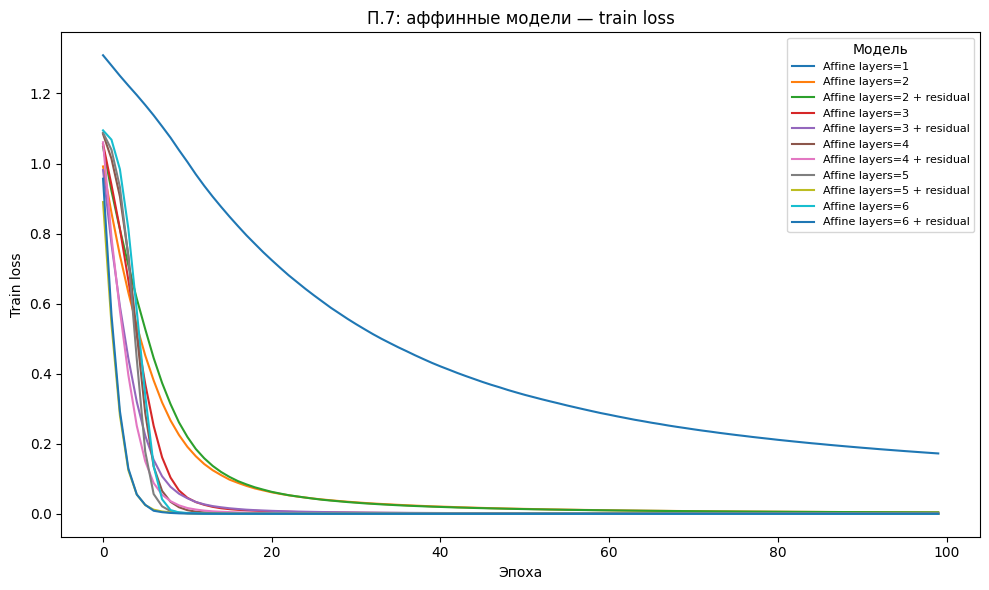

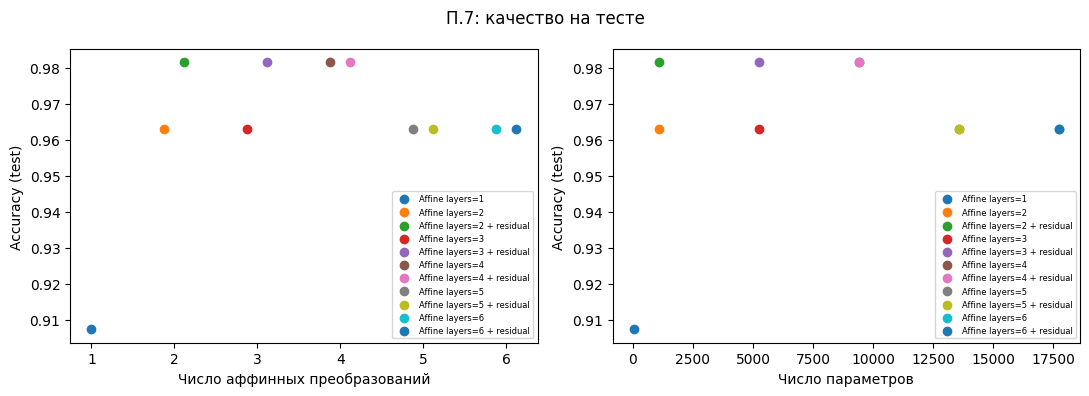

In [9]:
affine_configs = []
for n in [1, 2, 3, 4, 5, 6]:
    for res in [False, True]:
        if n == 1 and res:
            continue
        affine_configs.append(
            (
                f"affine_L{n}{'_res' if res else ''}",
                {
                    "d_in": d_in,
                    "num_classes": num_classes,
                    "n_affine": n,
                    "hidden": HIDDEN,
                    "activation": "relu",
                    "use_residual": res,
                },
            )
        )

results_affine = []
plt.figure(figsize=(10, 6))
for run_name, config_kwargs in affine_configs:
    print("Обучение", run_name, "...")
    run_result = run_training_curves(
        run_name,
        build_mlp_affine,
        config_kwargs,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR_AFFINE,
        n_transforms_key="n_affine",
    )
    results_affine.append(run_result)
    plt.plot([item["loss"] for item in run_result["history"]], label=format_run_label(run_name))
plt.xlabel("Эпоха")
plt.ylabel("Train loss")
plt.title("П.7: аффинные модели — train loss")
plt.legend(fontsize=8, title="Модель")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
scatter_test_points(ax[0], results_affine, "n_transforms", spread=0.12)
scatter_test_points(ax[1], results_affine, "params", spread=0.12)
ax[0].set_xlabel("Число аффинных преобразований")
ax[0].set_ylabel("Accuracy (test)")
ax[1].set_xlabel("Число параметров")
ax[1].set_ylabel("Accuracy (test)")
for axis in ax:
    axis.legend(fontsize=6, scatterpoints=1)
plt.suptitle("П.7: качество на тесте")
plt.tight_layout()
plt.show()


## RBF-сети (п. 8)

Функции блока (п.8): RBF-преобразование `phi(x,c)=exp(-gamma ||x-c||^2)`, далее обучение и сравнение моделей по метрикам.

Обучение rbf_L1 ...
Обучение rbf_L2 ...
Обучение rbf_L2_res ...
Обучение rbf_L3 ...
Обучение rbf_L3_res ...
Обучение rbf_L4 ...
Обучение rbf_L4_res ...
Обучение rbf_L5 ...
Обучение rbf_L5_res ...


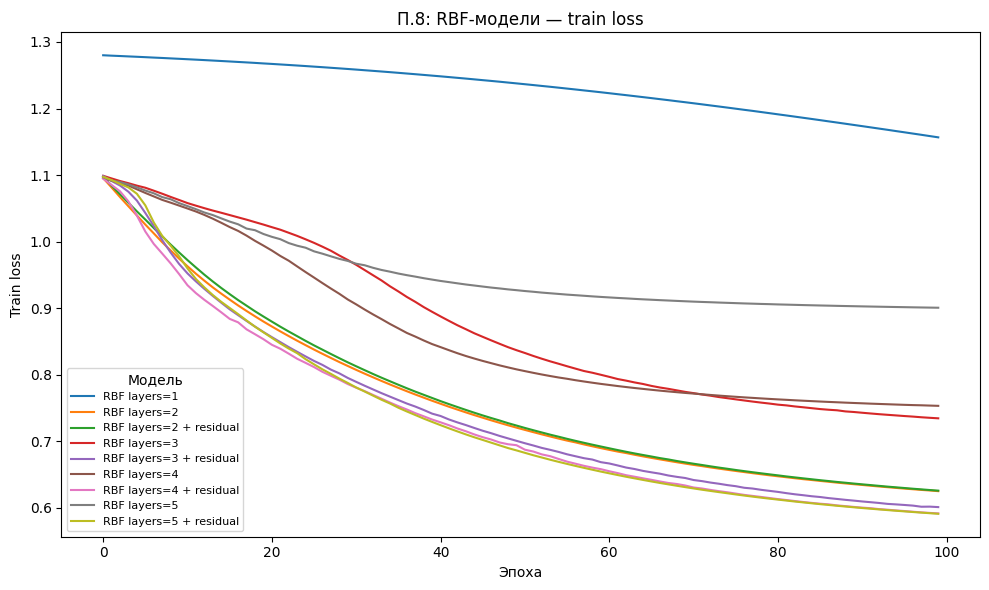

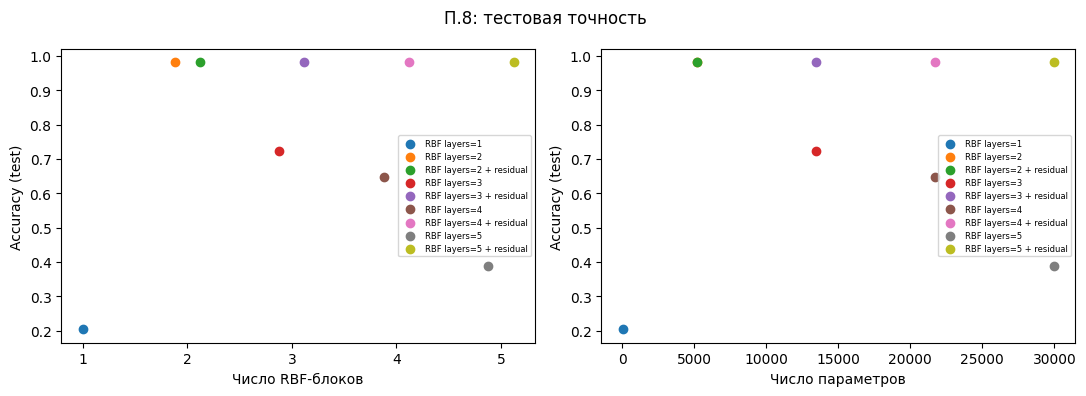

In [10]:
rbf_configs = []
for n in [1, 2, 3, 4, 5]:
    for res in [False, True]:
        if n == 1 and res:
            continue
        rbf_configs.append(
            (
                f"rbf_L{n}{'_res' if res else ''}",
                {
                    "d_in": d_in,
                    "num_classes": num_classes,
                    "n_rbf": n,
                    "hidden": HIDDEN,
                    "gamma": GAMMA_RBF,
                    "init_X": X_train,
                    "tail_activation": "tanh",
                    "use_residual": res,
                },
            )
        )

results_rbf = []
plt.figure(figsize=(10, 6))
for label, kw in rbf_configs:
    print("Обучение", label, "...")
    r = run_training_curves(
        label,
        build_mlp_rbf,
        kw,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR_RBF,
        n_transforms_key="n_rbf",
    )
    results_rbf.append(r)
    plt.plot([h["loss"] for h in r["history"]], label=format_run_label(label))
plt.xlabel("Эпоха")
plt.ylabel("Train loss")
plt.title("П.8: RBF-модели — train loss")
plt.legend(fontsize=8, title="Модель")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
scatter_test_points(ax[0], results_rbf, "n_transforms", spread=0.12)
scatter_test_points(ax[1], results_rbf, "params", spread=0.12)
ax[0].set_xlabel("Число RBF-блоков")
ax[0].set_ylabel("Accuracy (test)")
ax[1].set_xlabel("Число параметров")
ax[1].set_ylabel("Accuracy (test)")
for axis in ax:
    axis.legend(fontsize=6, scatterpoints=1)
plt.suptitle("П.8: тестовая точность")
plt.tight_layout()
plt.show()



## Мини-сравнение: влияние `gamma` для RBF

Быстрый sanity-check: сравниваем `gamma ∈ {0.1, 0.5, 1.0}` на одной и той же архитектуре RBF (без residual), чтобы зафиксировать, что выбранное значение адекватно.

,gamma,test_acc,test_f1
0,0.1,0.981481,0.981432
1,0.5,0.666667,0.617152
2,1.0,0.388889,0.217778


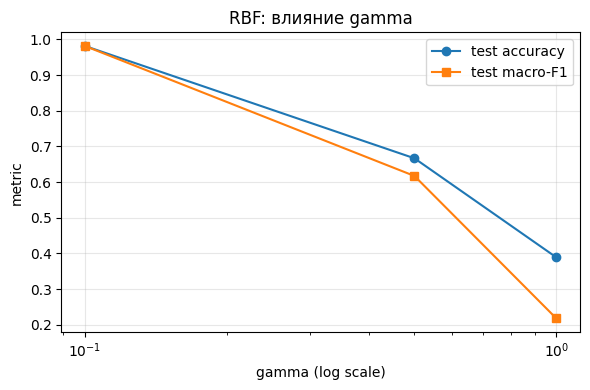

In [11]:
gamma_grid = [0.1, 0.5, 1.0]
gamma_results = []

for gamma_value in gamma_grid:
    run_result = run_training_curves(
        name=f"rbf_gamma_{gamma_value}",
        build_fn=build_mlp_rbf,
        build_kw={
            "d_in": d_in,
            "num_classes": num_classes,
            "n_rbf": 2,
            "hidden": HIDDEN,
            "gamma": gamma_value,
            "init_X": X_train,
            "tail_activation": "tanh",
            "use_residual": False,
        },
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        epochs=8,
        batch_size=BATCH_SIZE,
        lr=LR_RBF,
        n_transforms_key="n_rbf",
    )
    gamma_results.append({
        "gamma": gamma_value,
        "test_acc": run_result["test_acc"],
        "test_f1": run_result["test_f1"],
    })

gamma_df = pd.DataFrame(gamma_results).sort_values("gamma")
display(gamma_df)

plt.figure(figsize=(6, 4))
plt.plot(gamma_df["gamma"], gamma_df["test_acc"], marker="o", label="test accuracy")
plt.plot(gamma_df["gamma"], gamma_df["test_f1"], marker="s", label="test macro-F1")
plt.xscale("log")
plt.xlabel("gamma (log scale)")
plt.ylabel("metric")
plt.title("RBF: влияние gamma")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Смешанные Affine + RBF (п. 9)

Функции блока (п.9): смешанная архитектура из Affine и RBF-блоков, обучение по кросс-энтропии и сравнение кривых/качества.

Обучение mixed_B3 ...
Обучение mixed_B3_res ...
Обучение mixed_B4 ...
Обучение mixed_B4_res ...
Обучение mixed_B5 ...
Обучение mixed_B5_res ...
Обучение mixed_B6 ...
Обучение mixed_B6_res ...
Обучение mixed_B7 ...
Обучение mixed_B7_res ...


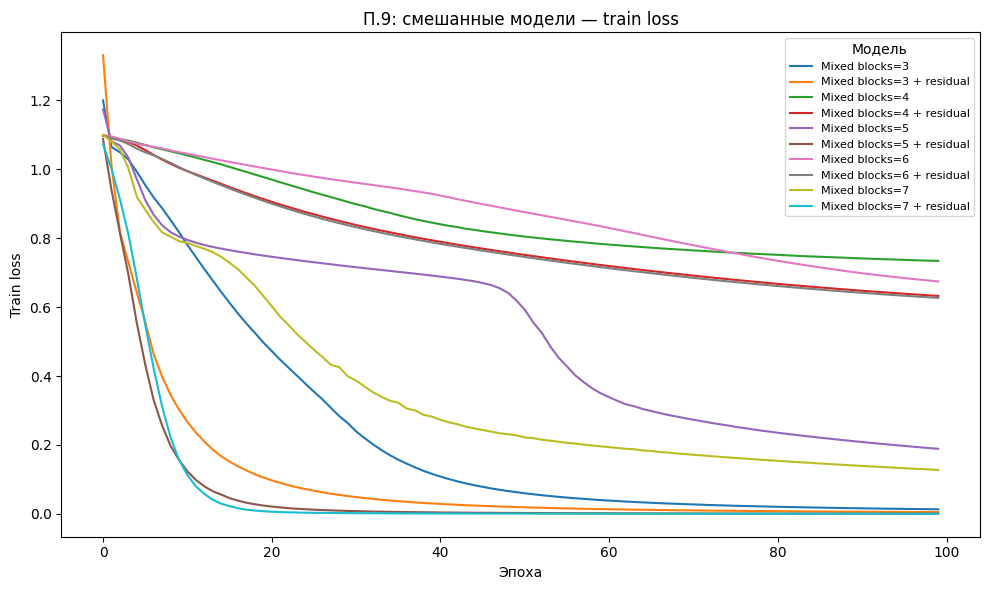

In [12]:
mixed_configs = []
for n_blocks in [3, 4, 5, 6, 7]:
    for res in [False, True]:
        mixed_configs.append(
            (
                f"mixed_B{n_blocks}{'_res' if res else ''}",
                {
                    "d_in": d_in,
                    "num_classes": num_classes,
                    "n_blocks": n_blocks,
                    "hidden": HIDDEN,
                    "activation": "relu",
                    "gamma": GAMMA_RBF,
                    "init_X": X_train,
                    "use_residual": res,
                },
            )
        )

results_mixed = []
plt.figure(figsize=(10, 6))
for run_name, config_kwargs in mixed_configs:
    print("Обучение", run_name, "...")
    run_result = run_training_curves(
        run_name,
        build_mlp_mixed,
        config_kwargs,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR_AFFINE,
        n_transforms_key="n_blocks",
    )
    results_mixed.append(run_result)
    plt.plot([item["loss"] for item in run_result["history"]], label=format_run_label(run_name))
plt.xlabel("Эпоха")
plt.ylabel("Train loss")
plt.title("П.9: смешанные модели — train loss")
plt.legend(fontsize=8, title="Модель")
plt.tight_layout()
plt.show()



## Сводная таблица

Функции блока: сводная таблица метрик по моделям (`test_acc`, `test_f1`, число параметров, число преобразований) для сравнения п.7–9.

In [13]:
rows = []
for group, res in [("Affine", results_affine), ("RBF", results_rbf), ("Mixed", results_mixed)]:
    for r in res:
        rows.append(
            {
                "group": group,
                "name": r["name"],
                "test_acc": r["test_acc"],
                "test_f1": r["test_f1"],
                "params": r["params"],
                "n_tr": r["n_transforms"],
            }
        )
df = pd.DataFrame(rows)
for g in df["group"].unique():
    print("\n===", g, "===")
    display(df[df["group"] == g].sort_values("test_acc", ascending=False))



=== Affine ===


,group,name,test_acc,test_f1,params,n_tr
2,Affine,affine_L2_res,0.981481,0.981554,1091,2
4,Affine,affine_L3_res,0.981481,0.981554,5251,3
5,Affine,affine_L4,0.981481,0.981554,9411,4
6,Affine,affine_L4_res,0.981481,0.981554,9411,4
1,Affine,affine_L2,0.962963,0.963194,1091,2
3,Affine,affine_L3,0.962963,0.963194,5251,3
7,Affine,affine_L5,0.962963,0.963194,13571,5
8,Affine,affine_L5_res,0.962963,0.963194,13571,5
9,Affine,affine_L6,0.962963,0.962586,17731,6
10,Affine,affine_L6_res,0.962963,0.962586,17731,6



=== RBF ===


,group,name,test_acc,test_f1,params,n_tr
12,RBF,rbf_L2,0.981481,0.981554,5184,2
13,RBF,rbf_L2_res,0.981481,0.981554,5184,2
15,RBF,rbf_L3_res,0.981481,0.981554,13440,3
17,RBF,rbf_L4_res,0.981481,0.981554,21696,4
19,RBF,rbf_L5_res,0.981481,0.981554,29952,5
14,RBF,rbf_L3,0.722222,0.619883,13440,3
16,RBF,rbf_L4,0.648148,0.566135,21696,4
18,RBF,rbf_L5,0.388889,0.217778,29952,5
11,RBF,rbf_L1,0.203704,0.184148,39,1



=== Mixed ===


,group,name,test_acc,test_f1,params,n_tr
20,Mixed,mixed_B3,0.981481,0.981554,5187,3
21,Mixed,mixed_B3_res,0.981481,0.981554,5187,3
25,Mixed,mixed_B5_res,0.981481,0.981554,13443,5
27,Mixed,mixed_B6_res,0.981481,0.981554,17600,6
29,Mixed,mixed_B7_res,0.981481,0.981554,21699,7
23,Mixed,mixed_B4_res,0.962963,0.962586,9344,4
24,Mixed,mixed_B5,0.962963,0.962586,13443,5
28,Mixed,mixed_B7,0.944444,0.943715,21699,7
26,Mixed,mixed_B6,0.907407,0.905154,17600,6
22,Mixed,mixed_B4,0.703704,0.602102,9344,4
